In [1]:
import pandas as pd
from pathlib import Path
from glob import glob
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [ ]:
root = Path("/local/home/osophie/HeadEntropy")
datasets = ["tables_triv_trace_jacobian_answer" ,"tables_hot_trace_jacobian_answer", "tables_indmed_trace_jacobian_answer"] #, "tables_all", "tables_all_", "tables_hot_trace_jacobian_question", "tables_indmed_trace_jacobian_question", "tables_triv_trace_jacobian_question"] #, "tables_all", "tables_all_lookback_lens_ratio"]
models = ["Qwen3-8B", "Qwen3-1.7B", "Llama-3.1-8B-Instruct",  "Qwen3-32B", "gemma-4-12b-it"] # "Llama-3.2-3B-Instruct"

In [ ]:

def read_auc_test(csv_path: Path, model: str):
    if model == "Qwen3-8B":
        layer = "he_logistic_regression_36"
    elif model == "Qwen3-1.7B":
        layer = "he_logistic_regression_28"
    elif model == "Llama-3.1-8B-Instruct":
        layer = "he_logistic_regression_32"
    elif model == "Llama-3.2-3B-Instruct":
        layer = "he_logistic_regression_28"
    elif model == "Qwen3-32B":
        layer = "he_logistic_regression_64"
    elif model == "gemma-4-12b-it":
        layer = "he_logistic_regression_48"
    try:
        df_csv = pd.read_csv(csv_path)
        if "roc_auc_test" not in df_csv.columns or df_csv.empty:
            return float('nan')
        hit = df_csv.loc[df_csv["name"] == layer, "roc_auc_test"]
        if hit.empty:                      # row never written by this run
            return float('nan')
        return hit.iloc[0] if pd.notna(hit.iloc[0]) else float('nan')
    except FileNotFoundError:
        return float('nan')
    except Exception as e:
        print(f"[warn] could not read {csv_path}: {e}")
        return float('nan')

def read_metric(csv_path: Path, metric:str):
    try:
        df_csv = pd.read_csv(csv_path)
        if "roc_auc_test" not in df_csv.columns or df_csv.empty:
            return float('nan')
        hit = df_csv.loc[df_csv["name"] == metric, "roc_auc_test"]
        if hit.empty:
            return float('nan')
        return hit.iloc[0] if pd.notna(hit.iloc[0]) else float('nan')
    except FileNotFoundError:
        return float('nan')
    except Exception as e:
        print(f"[warn] could not read {csv_path}: {e}")
        return float('nan')

In [ ]:
# get latex_results.csv
rows = []
for dataset in datasets:
    for model in models:
        if model == "Qwen3-32B" and (dataset == "tables_hot_renyi_answer" or dataset == "tables_hot_renyi_question"):
            continue
        base = root / dataset / model
        glob_path = base / "latex_results_*.csv"
        matched_files = list(glob(str(glob_path)))
        if matched_files:
            latest_file = Path(max(matched_files, key=os.path.getmtime))
        else:
            print(f"no results for {glob_path}")
            continue
        if not latest_file.exists():
            print(f"[warn] no results for {latest_file}")
            continue

        if "triv" in dataset:
            dataset_token = "TriviaQA"
        elif "indmed" in dataset:
            dataset_token = "MedMCQA"
        elif "hot" in dataset:
            dataset_token = "HotpotQA"
        elif "all" in dataset:
            dataset_token = "TriviaQA"
        else:
            print(f"[warn] unknown dataset {dataset}, skipping")
            continue

        df_one = {}
        df_one["head_entropy"] = read_auc_test(latest_file, model)
        df_one["dataset"] = dataset_token
        df_one["model"] = model
        df_one["source"] = str(latest_file)
        df_one["section"] = "answer" if "answer" in dataset else "question"

        list_metrics = [
            "lookback_lens_ratio",
            "logistic_regression_med", "logistic_regression_med_lr", "logistic_regression_med_hs",
            "logistic_regression_hotpot", "logistic_regression_hotpot_lr", "logistic_regression_hotpot_hs",
            "logistic_regression_math", "logistic_regression_math_lr", "logistic_regression_math_hs",
            "logistic_regression_fever", "logistic_regression_fever_lr", "logistic_regression_fever_hs",
            "attn_score", "token_probs", "token_entropy", "model_confidence",
            "mean_he", "mean_lr", "mean_hs", "mean_icr",
            "hidden_state_score",
            "icr_score",
            "logistic_regression_med_icr", "logistic_regression_hotpot_icr",
            "logistic_regression_math_icr", "logistic_regression_fever_icr",
            "mean_math", "mean_math_lr", "mean_math_hs",
            "mean_fever", "mean_fever_lr", "mean_fever_hs",
            "mean_math_icr", "mean_fever_icr",
            "attn_score_math", "attn_score_fever",
            "token_probs_math", "token_probs_fever",
            "token_entropy_math", "token_entropy_fever",
            "model_confidence_math", "model_confidence_fever",
        ]

        for metric in list_metrics:
            val = read_metric(latest_file, metric)
            if val is None or pd.isna(val):
                print(f"[warn] metric {metric} is missing or NaN in {latest_file}")
                continue
            df_one[metric] = val

        rows.append(df_one)

df = pd.DataFrame(rows)
df

[warn] metric logistic_regression_hotpot is missing or NaN in /local/home/osophie/HeadEntropy/tables_triv_trace_jacobian_answer/Qwen3-32B/latex_results_20260829_203750.csv
[warn] metric logistic_regression_hotpot_lr is missing or NaN in /local/home/osophie/HeadEntropy/tables_triv_trace_jacobian_answer/Qwen3-32B/latex_results_20260829_203750.csv
[warn] metric logistic_regression_hotpot_hs is missing or NaN in /local/home/osophie/HeadEntropy/tables_triv_trace_jacobian_answer/Qwen3-32B/latex_results_20260829_203750.csv
[warn] metric logistic_regression_hotpot_icr is missing or NaN in /local/home/osophie/HeadEntropy/tables_triv_trace_jacobian_answer/Qwen3-32B/latex_results_20260829_203750.csv
no results for /local/home/osophie/HeadEntropy/tables_hot_trace_jacobian_answer/Qwen3-32B/latex_results_*.csv
[warn] metric logistic_regression_hotpot is missing or NaN in /local/home/osophie/HeadEntropy/tables_indmed_trace_jacobian_answer/Qwen3-32B/latex_results_20260829_211001.csv
[warn] metric logi

,head_entropy,dataset,model,source,section,lookback_lens_ratio,logistic_regression_med,logistic_regression_med_lr,logistic_regression_med_hs,logistic_regression_hotpot,...,mean_math_icr,mean_fever_icr,attn_score_math,attn_score_fever,token_probs_math,token_probs_fever,token_entropy_math,token_entropy_fever,model_confidence_math,model_confidence_fever
0,0.891709,TriviaQA,Qwen3-8B,/local/home/osophie/HeadEntropy/tables_triv_tr...,answer,0.854364,0.906491,0.645875,0.882971,0.739223,...,0.477508,0.470222,0.980598,0.503248,0.956323,0.612590,0.954175,0.597665,0.977963,0.671270
1,0.894221,TriviaQA,Qwen3-1.7B,/local/home/osophie/HeadEntropy/tables_triv_tr...,answer,0.878164,0.809736,0.616862,0.814018,0.747256,...,0.242055,0.338681,0.986265,0.601323,0.607721,0.629750,0.544067,0.619894,0.963172,0.630608
2,0.879398,TriviaQA,Llama-3.1-8B-Instruct,/local/home/osophie/HeadEntropy/tables_triv_tr...,answer,0.882485,0.542125,0.559213,0.547264,0.721105,...,0.441102,0.474712,0.519972,0.509486,0.729611,0.644629,0.729253,0.664960,0.506440,0.502182
3,0.877343,TriviaQA,Qwen3-32B,/local/home/osophie/HeadEntropy/tables_triv_tr...,answer,0.863108,0.781121,0.657905,0.785189,NaN,...,0.441097,0.513151,0.973768,0.467117,0.608627,0.502109,0.622176,0.505028,0.491144,0.657685
4,0.908305,TriviaQA,gemma-4-12b-it,/local/home/osophie/HeadEntropy/tables_triv_tr...,answer,0.857383,0.886498,0.686925,0.900519,0.729589,...,0.769258,0.749882,0.948199,0.664809,0.672870,0.516563,0.651935,0.504214,0.499267,0.632466
5,0.848272,HotpotQA,Qwen3-8B,/local/home/osophie/HeadEntropy/tables_hot_tra...,answer,0.744067,0.896572,0.375171,0.872562,0.692127,...,0.477508,0.470222,0.980598,0.503248,0.956323,0.612590,0.954175,0.597665,0.977963,0.671270
6,0.873857,HotpotQA,Qwen3-1.7B,/local/home/osophie/HeadEntropy/tables_hot_tra...,answer,0.763414,0.845600,0.645641,0.851552,0.695674,...,0.242055,0.338681,0.986265,0.601323,0.607721,0.629750,0.544067,0.619894,0.963172,0.630608
7,0.857889,HotpotQA,Llama-3.1-8B-Instruct,/local/home/osophie/HeadEntropy/tables_hot_tra...,answer,0.848801,0.595912,0.578668,0.554572,0.640297,...,0.441102,0.474712,0.519972,0.509486,0.729611,0.644629,0.729253,0.664960,0.506440,0.502182
8,0.828160,HotpotQA,gemma-4-12b-it,/local/home/osophie/HeadEntropy/tables_hot_tra...,answer,0.723409,0.891788,0.648801,0.865612,0.808323,...,0.769258,0.749882,0.948199,0.664809,0.672870,0.516563,0.651935,0.504214,0.499267,0.632466
9,0.910578,MedMCQA,Qwen3-8B,/local/home/osophie/HeadEntropy/tables_indmed_...,answer,0.822006,0.667703,0.816567,0.721158,0.568102,...,0.477508,0.470222,0.980598,0.503248,0.956323,0.612590,0.954175,0.597665,0.977963,0.671270


In [5]:
answer_df = df[df["section"] == "answer"].drop(columns=[ "source","section"])
answer_df.sort_values(by=[ "model"], inplace=True)
answer_df

def gen_mean(frame, cols):
    """Row-wise mean over the generalization columns that actually made it into
    the table. Runs predating a metric simply have no column for it, so this
    yields NaN for that method instead of raising."""
    present = [c for c in cols if c in frame.columns]
    missing = [c for c in cols if c not in frame.columns]
    if missing:
        print(f"[warn] generalization columns absent from all runs: {missing}")
    if not present:
        return float("nan")
    cov = frame[present].notna().sum(axis=1)
    for i in frame.index[cov < len(present)]:
        gaps = [c for c in present if pd.isna(frame.loc[i, c])]
        print(f"[warn] {frame.loc[i, 'model']} / {frame.loc[i, 'dataset']}: averaging "
              f"{cov[i]}/{len(present)} sets, missing {gaps}")
    return frame[present].mean(axis=1)

gen_sets = ["med", "hotpot", "math", "fever"]
answer_df["gen_he"]  = gen_mean(answer_df, [f"logistic_regression_{d}" for d in gen_sets])
answer_df["gen_lb"]  = gen_mean(answer_df, [f"logistic_regression_{d}_lr" for d in gen_sets])
answer_df["gen_hs"]  = gen_mean(answer_df, [f"logistic_regression_{d}_hs" for d in gen_sets])
answer_df["gen_icr"] = gen_mean(answer_df, [f"logistic_regression_{d}_icr" for d in gen_sets])

final_df = answer_df.groupby("model").mean(numeric_only=True)

grouped = answer_df.groupby("model")
for col, suffix in {"mean_he": "", "mean_lr": "_lr", "mean_hs": "_hs"}.items():
    extra_cols = [c for c in (f"mean_math{suffix}", f"mean_fever{suffix}") if c in answer_df.columns]
    if col not in answer_df.columns or not extra_cols:
        print(f"[warn] cannot build 5-dataset unsupervised average for {col}")
        continue
    in_domain = grouped[col].agg(["sum", "count"])
    extra = grouped[extra_cols].first()
    final_df[col] = (in_domain["sum"] + extra.sum(axis=1)) / (in_domain["count"] + extra.notna().sum(axis=1))

# Add average row at the bottom
final_df.loc["average"] = final_df.mean()
final_df.drop(columns=[f"logistic_regression_{d}{s}" for d in gen_sets for s in ("", "_lr", "_hs", "_icr")]
                      + ["mean_math", "mean_math_lr", "mean_math_hs", "mean_fever", "mean_fever_lr", "mean_fever_hs"],
              inplace=True, errors="ignore")
# order 
final_df = final_df[["lookback_lens_ratio", "hidden_state_score", "icr_score", "head_entropy",
                     "gen_lb", "gen_hs", "gen_icr", "gen_he",
                     "attn_score", "token_probs",
                     "mean_lr", "mean_hs", "mean_he"]]
print(final_df.T.to_markdown(floatfmt=".3f"))

[warn] Qwen3-32B / TriviaQA: averaging 3/4 sets, missing ['logistic_regression_hotpot']
[warn] Qwen3-32B / MedMCQA: averaging 3/4 sets, missing ['logistic_regression_hotpot']
[warn] Qwen3-32B / TriviaQA: averaging 3/4 sets, missing ['logistic_regression_hotpot_lr']
[warn] Qwen3-32B / MedMCQA: averaging 3/4 sets, missing ['logistic_regression_hotpot_lr']
[warn] Qwen3-32B / TriviaQA: averaging 3/4 sets, missing ['logistic_regression_hotpot_hs']
[warn] Qwen3-32B / MedMCQA: averaging 3/4 sets, missing ['logistic_regression_hotpot_hs']
[warn] Qwen3-32B / TriviaQA: averaging 3/4 sets, missing ['logistic_regression_hotpot_icr']
[warn] Qwen3-32B / MedMCQA: averaging 3/4 sets, missing ['logistic_regression_hotpot_icr']
|                     |   Llama-3.1-8B-Instruct |   Qwen3-1.7B |   Qwen3-32B |   Qwen3-8B |   gemma-4-12b-it |   average |
|:--------------------|------------------------:|-------------:|------------:|-----------:|-----------------:|----------:|
| lookback_lens_ratio |           

In [6]:
import pandas as pd
import numpy as np

# For each eval dataset, the mapping of LR-key in column name -> actual training dataset
train_map = {
    'TriviaQA': {'med': 'med',  'hotpot': 'hotpot', 'math': 'math', 'fever': 'fever'},
    'HotpotQA': {'med': 'med',  'hotpot': 'triv',   'math': 'math', 'fever': 'fever'},
    'MedMCQA':  {'med': 'triv', 'hotpot': 'hotpot', 'math': 'math', 'fever': 'fever'},
}

methods = {
    'head_entropy':  '',
    'lookback_lens': '_lr',
    'hidden_states': '_hs',
    'icr':           '_icr',
}

lr_keys = ['med', 'hotpot', 'math', 'fever']
out_train_cols = ['fever', 'hotpot', 'math', 'med', 'triv']

# accumulate values per (method, actual_train_ds)
buckets = {(m, t): [] for m in methods for t in out_train_cols}

for method_name, suffix in methods.items():
    for lr_key in lr_keys:
        col_name = f'logistic_regression_{lr_key}{suffix}'
        if col_name not in df.columns:
            continue
        for idx in df.index:
            eval_ds = df.loc[idx, 'dataset']
            if eval_ds not in train_map:
                continue
            actual_train = train_map[eval_ds][lr_key]  # remap via swap rule
            v = pd.to_numeric(df.loc[idx, col_name], errors='coerce')
            if pd.notna(v):
                buckets[(method_name, actual_train)].append(v)

result = pd.DataFrame(
    {(m, t): (np.mean(buckets[(m, t)]) if buckets[(m, t)] else np.nan)
     for m in methods for t in out_train_cols},
    index=[0],
).T.unstack().droplevel(0, axis=1) if False else \
pd.Series({k: (np.mean(v) if v else np.nan) for k, v in buckets.items()}).unstack()

result = result[out_train_cols]
result['mean'] = result.mean(axis=1)
print(result.to_string())

                  fever    hotpot      math       med      triv      mean
head_entropy   0.659296  0.697458  0.813143  0.795094  0.706906  0.734379
hidden_states  0.660393  0.696374  0.832964  0.786029  0.717861  0.738724
icr            0.608787  0.642638  0.587605  0.666633  0.702853  0.641703
lookback_lens  0.614625  0.612344  0.566922  0.601673  0.665696  0.612252


In [7]:

unsup_methods = {
    'head_entropy':     ('mean_he',          'mean_{ds}'),
    'lookback_lens':    ('mean_lr',          'mean_{ds}_lr'),
    'hidden_states':    ('mean_hs',          'mean_{ds}_hs'),
    'icr':              ('mean_icr',         'mean_{ds}_icr'),
    'attn_score':       ('attn_score',       'attn_score_{ds}'),
    # 'token_probs':      ('token_probs',      'token_probs_{ds}'),
    'token_entropy':    ('token_entropy',    'token_entropy_{ds}'),
    'model_confidence': ('model_confidence', 'model_confidence_{ds}'),
}
eval_token = {'TriviaQA': 'triv', 'HotpotQA': 'hotpot', 'MedMCQA': 'med'}

unsup_buckets = {(m, d): [] for m in unsup_methods for d in out_train_cols}

for method_name, (in_domain_col, gen_tpl) in unsup_methods.items():
    for model, grp in df.groupby('model'):
        # in-domain: one row per evaluated dataset, so one value per model per column
        if in_domain_col in grp.columns:
            for idx in grp.index:
                col_ds = eval_token.get(grp.loc[idx, 'dataset'])
                v = pd.to_numeric(grp.loc[idx, in_domain_col], errors='coerce')
                if col_ds is not None and pd.notna(v):
                    unsup_buckets[(method_name, col_ds)].append(v)
        # math / fever: the same score repeated on every row of this model -> one value
        for ds in ('math', 'fever'):
            col = gen_tpl.format(ds=ds)
            if col not in grp.columns:
                continue
            vals = pd.to_numeric(grp[col], errors='coerce').dropna()
            if len(vals):
                unsup_buckets[(method_name, ds)].append(vals.mean())

unsup_result = pd.Series(
    {k: (np.mean(v) if v else np.nan) for k, v in unsup_buckets.items()}
).unstack()
unsup_result = unsup_result[out_train_cols]
unsup_result['mean'] = unsup_result.mean(axis=1)
print(unsup_result.to_string())

                     fever    hotpot      math       med      triv      mean
attn_score        0.549197  0.616395  0.881761  0.721269  0.658745  0.685473
head_entropy      0.632370  0.667795  0.879427  0.806138  0.693118  0.735770
hidden_states     0.424584  0.484325  0.287527  0.398806  0.420766  0.403201
icr               0.509330  0.491419  0.474204  0.499780  0.482350  0.491416
lookback_lens     0.355008  0.404008  0.624490  0.404486  0.280693  0.413737
model_confidence  0.618842  0.620896  0.687597  0.688754  0.656670  0.654552
token_entropy     0.578352  0.656847  0.700321  0.683809  0.609124  0.645691


In [8]:
df

,head_entropy,dataset,model,source,section,lookback_lens_ratio,logistic_regression_med,logistic_regression_med_lr,logistic_regression_med_hs,logistic_regression_hotpot,...,mean_math_icr,mean_fever_icr,attn_score_math,attn_score_fever,token_probs_math,token_probs_fever,token_entropy_math,token_entropy_fever,model_confidence_math,model_confidence_fever
0,0.891709,TriviaQA,Qwen3-8B,/local/home/osophie/HeadEntropy/tables_triv_tr...,answer,0.854364,0.906491,0.645875,0.882971,0.739223,...,0.477508,0.470222,0.980598,0.503248,0.956323,0.612590,0.954175,0.597665,0.977963,0.671270
1,0.894221,TriviaQA,Qwen3-1.7B,/local/home/osophie/HeadEntropy/tables_triv_tr...,answer,0.878164,0.809736,0.616862,0.814018,0.747256,...,0.242055,0.338681,0.986265,0.601323,0.607721,0.629750,0.544067,0.619894,0.963172,0.630608
2,0.879398,TriviaQA,Llama-3.1-8B-Instruct,/local/home/osophie/HeadEntropy/tables_triv_tr...,answer,0.882485,0.542125,0.559213,0.547264,0.721105,...,0.441102,0.474712,0.519972,0.509486,0.729611,0.644629,0.729253,0.664960,0.506440,0.502182
3,0.877343,TriviaQA,Qwen3-32B,/local/home/osophie/HeadEntropy/tables_triv_tr...,answer,0.863108,0.781121,0.657905,0.785189,NaN,...,0.441097,0.513151,0.973768,0.467117,0.608627,0.502109,0.622176,0.505028,0.491144,0.657685
4,0.908305,TriviaQA,gemma-4-12b-it,/local/home/osophie/HeadEntropy/tables_triv_tr...,answer,0.857383,0.886498,0.686925,0.900519,0.729589,...,0.769258,0.749882,0.948199,0.664809,0.672870,0.516563,0.651935,0.504214,0.499267,0.632466
5,0.848272,HotpotQA,Qwen3-8B,/local/home/osophie/HeadEntropy/tables_hot_tra...,answer,0.744067,0.896572,0.375171,0.872562,0.692127,...,0.477508,0.470222,0.980598,0.503248,0.956323,0.612590,0.954175,0.597665,0.977963,0.671270
6,0.873857,HotpotQA,Qwen3-1.7B,/local/home/osophie/HeadEntropy/tables_hot_tra...,answer,0.763414,0.845600,0.645641,0.851552,0.695674,...,0.242055,0.338681,0.986265,0.601323,0.607721,0.629750,0.544067,0.619894,0.963172,0.630608
7,0.857889,HotpotQA,Llama-3.1-8B-Instruct,/local/home/osophie/HeadEntropy/tables_hot_tra...,answer,0.848801,0.595912,0.578668,0.554572,0.640297,...,0.441102,0.474712,0.519972,0.509486,0.729611,0.644629,0.729253,0.664960,0.506440,0.502182
8,0.828160,HotpotQA,gemma-4-12b-it,/local/home/osophie/HeadEntropy/tables_hot_tra...,answer,0.723409,0.891788,0.648801,0.865612,0.808323,...,0.769258,0.749882,0.948199,0.664809,0.672870,0.516563,0.651935,0.504214,0.499267,0.632466
9,0.910578,MedMCQA,Qwen3-8B,/local/home/osophie/HeadEntropy/tables_indmed_...,answer,0.822006,0.667703,0.816567,0.721158,0.568102,...,0.477508,0.470222,0.980598,0.503248,0.956323,0.612590,0.954175,0.597665,0.977963,0.671270


In [9]:

import numpy as np
import matplotlib.pyplot as plt

IN_DOMAIN_COL = {'head_entropy': 'head_entropy', 'lookback_lens': 'lookback_lens_ratio',
                 'hidden_states': 'hidden_state_score', 'icr': 'icr_score'}

_recs = []
for _, r in df.iterrows():
    model, eval_ds = r['model'], r['dataset']
    if eval_ds not in eval_token:
        continue
    for meth, col in IN_DOMAIN_COL.items():                 # trained probe, own dataset
        v = pd.to_numeric(r.get(col), errors='coerce')
        if pd.notna(v):
            _recs.append(('in-distribution', meth, model, eval_token[eval_ds], v))
    for meth, sfx in methods.items():                       # trained probe, transferred
        for key in lr_keys:
            v = pd.to_numeric(r.get(f'logistic_regression_{key}{sfx}'), errors='coerce')
            if pd.notna(v):
                _recs.append(('out-of-distribution', meth, model, train_map[eval_ds][key], v))
    for meth, (in_col, tpl) in unsup_methods.items():       # nothing trained
        v = pd.to_numeric(r.get(in_col), errors='coerce')
        if pd.notna(v):
            _recs.append(('unsupervised', meth, model, eval_token[eval_ds], v))
        for s in ('math', 'fever'):
            v = pd.to_numeric(r.get(tpl.format(ds=s)), errors='coerce')
            if pd.notna(v):
                _recs.append(('unsupervised', meth, model, s, v))

# collapse repeated measurements of the same pair (e.g. med reached from two tables)
pairs = (pd.DataFrame(_recs, columns=['regime', 'method', 'model', 'dataset', 'auc'])
           .groupby(['regime', 'method', 'model', 'dataset'], as_index=False)['auc'].mean())

REGIMES = ['in-distribution', 'out-of-distribution', 'unsupervised']
HUE = dict(zip(REGIMES, ['#2a78d6', '#eb6834', '#1baf7a']))   # palette slots 1-3, in order
# (HUE and the ink tokens below are consumed by the figure in the next cell)
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#c9c8c3'

stats = (pairs.groupby(['regime', 'method'])['auc']
              .agg(n='size', mean='mean', sd='std').reset_index())
stats['se'] = stats['sd'] / np.sqrt(stats['n'])
print(stats.round(3).to_string(index=False))


             regime           method  n  mean    sd    se
    in-distribution     head_entropy 14 0.867 0.043 0.012
    in-distribution    hidden_states 14 0.867 0.054 0.014
    in-distribution              icr 14 0.765 0.055 0.015
    in-distribution    lookback_lens 14 0.816 0.055 0.015
out-of-distribution     head_entropy 24 0.738 0.119 0.024
out-of-distribution    hidden_states 24 0.741 0.110 0.023
out-of-distribution              icr 24 0.647 0.100 0.020
out-of-distribution    lookback_lens 24 0.617 0.067 0.014
       unsupervised       attn_score 24 0.688 0.173 0.035
       unsupervised     head_entropy 24 0.739 0.162 0.033
       unsupervised    hidden_states 24 0.400 0.195 0.040
       unsupervised              icr 24 0.491 0.180 0.037
       unsupervised    lookback_lens 24 0.414 0.152 0.031
       unsupervised model_confidence 24 0.656 0.143 0.029
       unsupervised    token_entropy 24 0.645 0.125 0.026


excluding Llama-3.2-3B-Instruct -- 5 models remain

             regime           method  n  mean    sd    se
    in-distribution     head_entropy 14 0.867 0.043 0.012
    in-distribution    hidden_states 14 0.867 0.054 0.014
    in-distribution              icr 14 0.765 0.055 0.015
    in-distribution    lookback_lens 14 0.816 0.055 0.015
out-of-distribution     head_entropy 24 0.738 0.119 0.024
out-of-distribution    hidden_states 24 0.741 0.110 0.023
out-of-distribution              icr 24 0.647 0.100 0.020
out-of-distribution    lookback_lens 24 0.617 0.067 0.014
       unsupervised       attn_score 24 0.688 0.173 0.035
       unsupervised     head_entropy 24 0.739 0.162 0.033
       unsupervised    hidden_states 24 0.600 0.195 0.040
       unsupervised              icr 24 0.491 0.180 0.037
       unsupervised    lookback_lens 24 0.586 0.152 0.031
       unsupervised model_confidence 24 0.656 0.143 0.029
       unsupervised    token_entropy 24 0.645 0.125 0.026


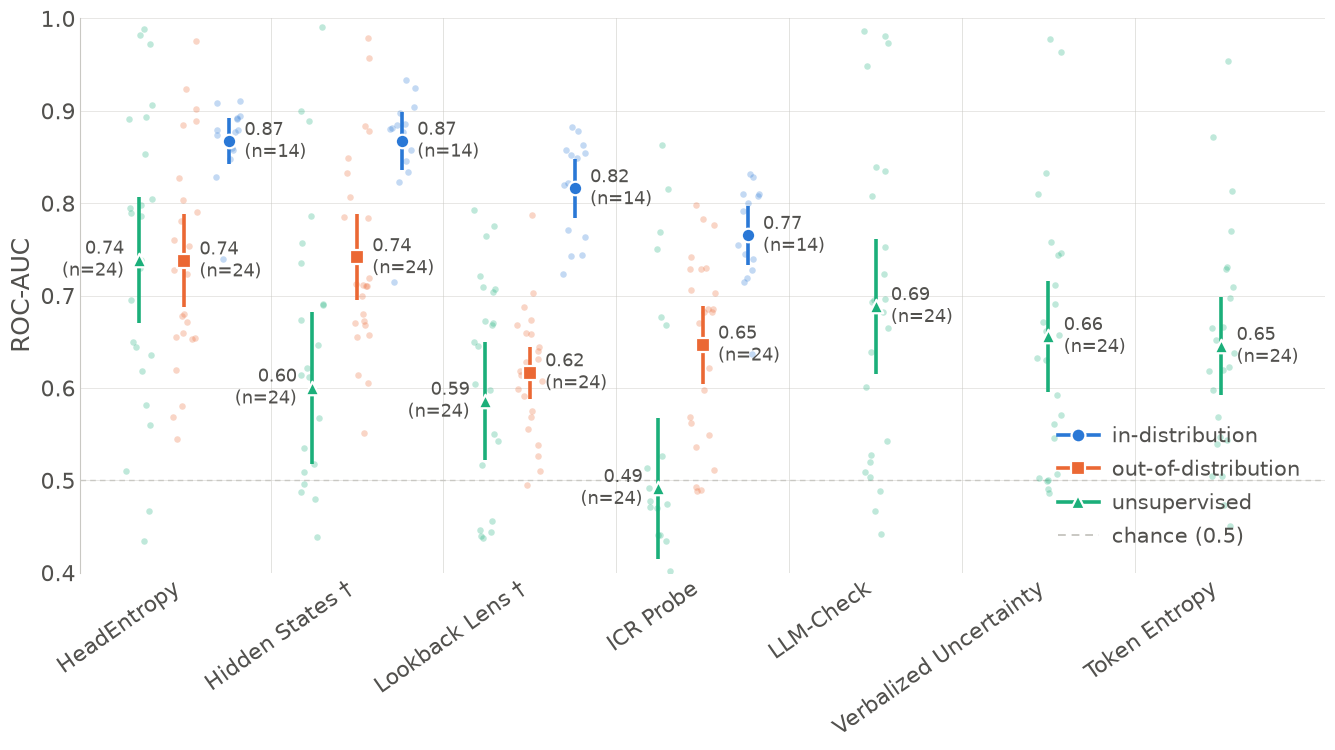

In [10]:
from scipy.stats import t as t_dist
EXCLUDE_MODELS = ['Llama-3.2-3B-Instruct']
cpairs = pairs[~pairs['model'].isin(EXCLUDE_MODELS)]

FLIP = {('unsupervised', 'hidden_states'), ('unsupervised', 'lookback_lens')}
        # ('unsupervised', 'icr')}
cpairs = cpairs.copy()
_flip = [(r, m) in FLIP for r, m in zip(cpairs['regime'], cpairs['method'])]
cpairs.loc[_flip, 'auc'] = 1 - cpairs.loc[_flip, 'auc']
FLIPPED_METHODS = {m for _, m in FLIP}

cstats = (cpairs.groupby(['regime', 'method'])['auc']
                .agg(n='size', mean='mean', sd='std').reset_index())
cstats['se'] = cstats['sd'] / np.sqrt(cstats['n'])
print(f"excluding {', '.join(EXCLUDE_MODELS)} -- "
      f"{cpairs['model'].nunique()} models remain\n")
print(cstats.round(3).to_string(index=False))

PRETTY = {
    'head_entropy':     'HeadEntropy',
    'hidden_states':    'Hidden States',
    'lookback_lens':    'Lookback Lens',
    'icr':              'ICR Probe',
    'model_confidence': 'Verbalized Uncertainty',
    'attn_score':       'LLM-Check',
    'token_probs':      'Token Probabilities',
    'token_entropy':    'Token Entropy',
}
_label = lambda m: PRETTY.get(m, m)

MARKER = dict(zip(REGIMES, ['o', 's', '^']))
DODGE = dict(zip(REGIMES, [0.26, 0.0, -0.26]))      # in-distribution highest in its row

_by_regime = cstats.set_index(['method', 'regime'])['mean']
_trained = sorted(cstats.loc[cstats['regime'] == 'in-distribution', 'method'])
_rank = lambda m: _by_regime.get((m, 'in-distribution' if m in _trained else 'unsupervised'))
order = (sorted([m for m in cstats['method'].unique() if m not in _trained], key=_rank)
         + sorted(_trained, key=_rank))
TOP = 'head_entropy'
if TOP in order:
    order = [m for m in order if m != TOP] + [TOP]   # last = best-ranked end
order = order[::-1]                                  # transposed: x index 0 is leftmost
x_of = {m: i for i, m in enumerate(order)}
n_regimes = cstats.groupby('method').size()

# all type sizes live here so the figure can be rescaled for a paper column in one place
FS_TICK, FS_AXLABEL, FS_ANNOT, FS_LEGEND = 16, 18, 13, 15
fig, ax = plt.subplots(figsize=(1.55 * len(order) + 2.6, 7.6))
rng = np.random.default_rng(0)

for i in range(len(order) - 1):                     # faint rule between methods
    ax.axvline(i + 0.5, color=GRID, lw=0.6, alpha=0.6, zorder=0)
ax.axhline(0.5, color=GRID, lw=1.0, ls=(0, (4, 3)), zorder=1)

for regime in REGIMES:
    for _, r in cstats[cstats['regime'] == regime].iterrows():
        x = x_of[r['method']] + (DODGE[regime] if n_regimes[r['method']] > 1 else 0.0)
        pts = cpairs.loc[(cpairs['regime'] == regime) &
                         (cpairs['method'] == r['method']), 'auc'].values
        ax.scatter(x + rng.uniform(-0.075, 0.075, len(pts)), pts, s=22,
                   facecolor=HUE[regime], alpha=0.28, linewidths=0, zorder=2)
        if pd.notna(r['se']):
            # same convention as the paired figure: Student's t at n-1 df, not 1.96
            _q = t_dist.ppf(0.975, int(r['n']) - 1)
            ax.vlines(x, r['mean'] - _q * r['se'], r['mean'] + _q * r['se'],
                      color=HUE[regime], lw=2.6, zorder=3)
        ax.scatter(x, r['mean'], s=95, marker=MARKER[regime], facecolor=HUE[regime],
                   edgecolor='white', linewidths=1.6, zorder=4)
        dx = DODGE[regime] if n_regimes[r['method']] > 1 else 0.0
        right = dx >= 0        # leftmost regime labels left, the other two right
        ax.annotate(f"{r['mean']:.2f}\n(n={int(r['n'])})", (x, r['mean']),
                    textcoords='offset points', xytext=(11 if right else -11, 0),
                    ha='left' if right else 'right', va='center',
                    fontsize=FS_ANNOT, color=MUTED, zorder=5)

ax.set_xticks(range(len(order)))
ax.set_xticklabels([f"{_label(m)} \u2020" if m in FLIPPED_METHODS else _label(m)
                    for m in order], color=INK, rotation=35, ha='right',
                   fontsize=FS_TICK)
ax.set_xlim(-0.6, len(order) - 0.4)

YLO, YHI = 0.40, 1.0
_clipped = int(((cpairs['auc'] < YLO) | (cpairs['auc'] > YHI)).sum())
ax.set_ylim(YLO, YHI)
ax.set_ylabel("ROC-AUC", color=MUTED, fontsize=FS_AXLABEL)
ax.grid(axis='y', color=GRID, lw=0.6, alpha=0.5, zorder=0)
ax.set_axisbelow(True)
for s in ('top', 'right', 'bottom'):
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.tick_params(colors=MUTED, length=0, labelsize=FS_TICK)

handles = [Line2D([], [], ls='-', lw=2.6, marker=MARKER[rg], ms=10, color=HUE[rg],
                  mfc=HUE[rg], mec='white', mew=1.6, label=rg) for rg in REGIMES]
handles.append(Line2D([], [], color=GRID, lw=1.4, ls=(0, (4, 3)), label='chance (0.5)'))
ax.legend(handles=handles, loc='lower right', ncol=1,
          frameon=False, fontsize=FS_LEGEND, labelcolor=MUTED, handletextpad=0.6,
          borderaxespad=0.8, labelspacing=0.6)

fig.tight_layout()
plt.savefig("figures/pairs_by_regime_collapsed.png", dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

_tt = lambda s: _label(s)          # the caption names methods the way the axis does
_nmax = lambda rg: int(cstats.loc[cstats['regime'] == rg, 'n'].max())
_flipped = ", ".join(_tt(m) for m in sorted(FLIPPED_METHODS))
_excluded = ", ".join(_tt(m) for m in EXCLUDE_MODELS)


findfont: Failed to find font weight semibold, now using 700.


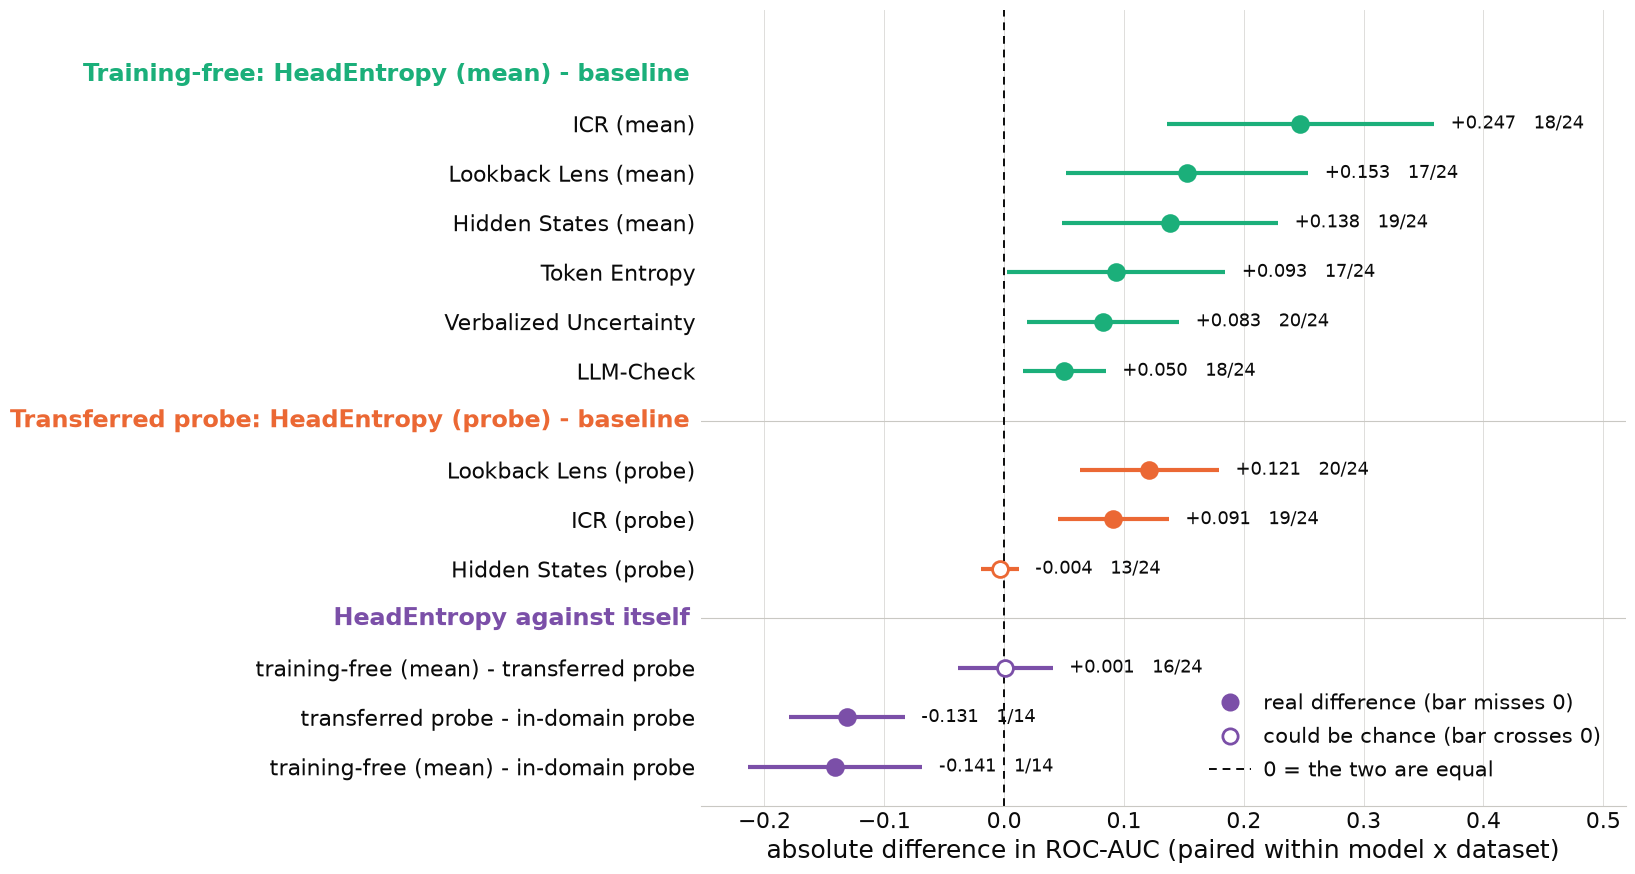

In [11]:
from scipy.stats import t as t_dist

REF = 'head_entropy'
MEAN_FEATURES = {'head_entropy', 'hidden_states', 'lookback_lens', 'icr'}
_base = lambda m: _label(m)[:-6] if _label(m).endswith(' Probe') else _label(m)
_ulabel = lambda m: _base(m) + (' (mean)' if m in MEAN_FEATURES else '')
_plabel = lambda m: _base(m) + ' (probe)'
ACROSS = '#7b4fa8'                       # cross-regime rows: no single regime colour

def paired(a_regime, a_meth, b_regime, b_meth):
    A = cpairs[(cpairs.regime == a_regime) & (cpairs.method == a_meth)].set_index(['model', 'dataset'])['auc']
    B = cpairs[(cpairs.regime == b_regime) & (cpairs.method == b_meth)].set_index(['model', 'dataset'])['auc']
    j = A.index.intersection(B.index)
    d = (A[j] - B[j]).values
    if len(d) < 2:
        return None
    se = d.std(ddof=1) / np.sqrt(len(d))
    q = t_dist.ppf(0.975, len(d) - 1)
    return dict(n=len(d), d=d.mean(), lo=d.mean() - q * se, hi=d.mean() + q * se,
                wins=int((d > 0).sum()))

# section -> (colour, [(label, spec_a, spec_b)]); rows are built then sorted by effect
_unsup = [m for m in cstats.loc[cstats.regime == 'unsupervised', 'method'] if m != REF]
_ood = [m for m in cstats.loc[cstats.regime == 'out-of-distribution', 'method'] if m != REF]
SECTIONS = [
    ("Training-free: HeadEntropy (mean) - baseline", HUE['unsupervised'],
     [(_ulabel(m), ('unsupervised', REF), ('unsupervised', m)) for m in _unsup]),
    ("Transferred probe: HeadEntropy (probe) - baseline", HUE['out-of-distribution'],
     [(_plabel(m), ('out-of-distribution', REF), ('out-of-distribution', m)) for m in _ood]),
    ("HeadEntropy against itself", ACROSS,
     [("training-free (mean) - transferred probe", ('unsupervised', REF), ('out-of-distribution', REF)),
      ("transferred probe - in-domain probe", ('out-of-distribution', REF), ('in-distribution', REF)),
      ("training-free (mean) - in-domain probe", ('unsupervised', REF), ('in-distribution', REF))]),
]

rows = []            # built bottom-up, so SECTIONS is walked in reverse to put the
                     # headline block (unsupervised) at the top of the finished figure
for title, colour, comps in reversed(SECTIONS):
    got = [(lab, paired(*a, *b)) for lab, a, b in comps]
    got = [(lab, s) for lab, s in got if s is not None]
    got.sort(key=lambda t: t[1]['d'])     # smallest effect at the bottom of its block
    rows.append((title, colour, got))

n_rows = sum(len(g) for _, _, g in rows)
fig, ax = plt.subplots(figsize=(16.5, 0.52 * n_rows + 2.6))

y, yticks, ylabels, seps, titles = 0, [], [], [], []
for title, colour, got in rows:
    for lab, s in got:
        solid = s['lo'] > 0 or s['hi'] < 0
        ax.hlines(y, s['lo'], s['hi'], color=colour, lw=3.0, zorder=3)
        ax.scatter(s['d'], y, s=130, marker='o', zorder=4, linewidths=2.0,
                   facecolor=colour if solid else 'white', edgecolor=colour)
        ax.annotate(f"{s['d']:+.3f}   {s['wins']}/{s['n']}", (max(s['hi'], s['d']), y),
                    textcoords='offset points', xytext=(12, 0), ha='left', va='center',
                    fontsize=FS_ANNOT, color=INK, zorder=5)
        yticks.append(y); ylabels.append(lab)
        y += 1
    titles.append((y - len(got) - 0.5 + len(got), title, colour))   # top of this block
    seps.append(y - 0.5)
    y += 1                                # blank row between sections

ax.axvline(0, color=INK, lw=1.4, ls=(0, (4, 3)), zorder=1)
for s in seps[:-1]:
    ax.axhline(s + 0.5, color=GRID, lw=0.8, zorder=0)
# section titles right-aligned on the axis spine, the same edge the method labels
# end on, so the left-hand column reads as one hierarchy instead of two
for ytop, title, colour in titles:
    ax.text(-0.012, ytop + 0.25, title, transform=ax.get_yaxis_transform(),
            ha='right', va='bottom', fontsize=FS_ANNOT + 4, color=colour,
            fontweight='semibold')

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, color=INK, fontsize=FS_TICK)
# +1.7 of headroom: the legend sits in the upper right and the widest interval
# (ICR Probe) is the top row, so without it the two collide
ax.set_ylim(-0.8, y - 0.4 + 0.7)
_span = [s for _, _, got in rows for _, s in got]
ax.set_xlim(min(v['lo'] for v in _span) - 0.04,
            max(v['hi'] for v in _span) + 0.16)   # label room
ax.set_xlabel("absolute difference in ROC-AUC (paired within model x dataset)",
              color=INK, fontsize=FS_AXLABEL)
ax.tick_params(colors=INK, length=0, labelsize=FS_TICK)
ax.grid(axis='x', color=GRID, lw=0.7, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
for s in ('top', 'right', 'left'):
    ax.spines[s].set_visible(False)
ax.spines['bottom'].set_color(GRID)

# plain-language legend: the filled/hollow split is the significance test, so it is
# named by what the reader should conclude rather than by the interval's arithmetic
handles = [Line2D([], [], ls='none', marker='o', ms=11, mfc=ACROSS, mec=ACROSS,
                  mew=2.0, label='real difference (bar misses 0)'),
           Line2D([], [], ls='none', marker='o', ms=11, mfc='white', mec=ACROSS,
                  mew=2.0, label='could be chance (bar crosses 0)'),
           Line2D([], [], color=INK, lw=1.4, ls=(0, (4, 3)), label='0 = the two are equal')]
# lower right: the bottom block is the only one with negative rows, so its bars sit
# left of zero and leave that corner empty
ax.legend(handles=handles, loc='lower right', ncol=1, frameon=False,
          fontsize=FS_LEGEND, labelcolor=INK, handletextpad=0.6,
          borderaxespad=0.8, labelspacing=0.6)

fig.tight_layout()
plt.savefig("figures/paired_differences.png", dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [13]:

REG_SHORT = {'in-distribution': 'in-dist.', 'out-of-distribution': 'transferred',
             'unsupervised': 'unsup. (mean)'}
REG_ORDER = ['in-distribution', 'out-of-distribution', 'unsupervised']
DS_NAME = {'triv': 'TriviaQA', 'hotpot': 'HotpotQA', 'med': 'MedMCQA',
           'math': 'MATH', 'fever': 'FEVER'}

def _panel(by):
    """mean AUC of HeadEntropy per level of `by`, one column per regime."""
    sub = cpairs[cpairs.method == REF]
    t = sub.pivot_table(index=by, columns='regime', values='auc', aggfunc='mean')
    n = sub.pivot_table(index=by, columns='regime', values='auc', aggfunc='size')
    return t.reindex(columns=REG_ORDER), n.reindex(columns=REG_ORDER)

def _rows(t, n, rename=None):
    for k in t.index:
        cells = []
        for rg in REG_ORDER:
            v, c = t.loc[k, rg], n.loc[k, rg]
            cells.append("--" if pd.isna(v) else f"{v:.3f}" + (r"\,\tiny{(%d)}" % c if pd.notna(c) else ""))
        print(f"    {rename.get(k, k) if rename else k} & " + " & ".join(cells) + r" \\")

t_m, n_m = _panel('model')
t_d, n_d = _panel('dataset')
t_d = t_d.reindex([d for d in ['triv', 'hotpot', 'med', 'math', 'fever'] if d in t_d.index])
n_d = n_d.reindex(t_d.index)

